---
Phase 5-LLM-3: 微調技術 — Full Fine-tuning → LoRA → QLoRA
---

預訓練好的 LLM 很強，但可能不懂你的專業領域。
微調 = 在你的資料上繼續訓練，讓模型學會特定任務。

問題：LLM 太大了！
  LLaMA-7B 有 70 億參數 → 全部微調需要 ~56 GB GPU 記憶體
  一般人根本沒有那麼大的 GPU

解法：LoRA — 只訓練一小部分參數，效果幾乎一樣好！

本檔涵蓋：
  1. Full Fine-tuning 的問題
  2. LoRA 的原理（從零實作）
  3. QLoRA — 量化 + LoRA
  4. 實作：用 LoRA 微調模型
  5. PEFT 實務

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================================
# 1. Full Fine-tuning 的問題
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print("=" * 60)
print("1. Full Fine-tuning — 太貴了！")
print("=" * 60)

print("""
Full Fine-tuning：更新模型的「所有」參數

  問題：
  1. GPU 記憶體：
     模型參數 (fp32):     4 bytes × 7B = 28 GB
     梯度:                28 GB
     Adam 優化器狀態:      56 GB (m + v)
     總共:                ~112 GB → 需要多張 A100！

  2. 存儲：
     每個任務都要存一份完整模型 → 7B × 4 bytes = 28 GB/任務

  3. 過擬合：
     用少量資料微調全部參數 → 容易過擬合

  解法：Parameter-Efficient Fine-Tuning (PEFT)
    只更新一小部分參數，凍結其他的

  PEFT 方法：
    - Adapter: 在每層插入小的 bottleneck 層
    - Prefix Tuning: 在輸入前加上可學習的 token
    - LoRA: 低秩矩陣分解（最受歡迎！）
""")

1. Full Fine-tuning — 太貴了！

Full Fine-tuning：更新模型的「所有」參數

  問題：
  1. GPU 記憶體：
     模型參數 (fp32):     4 bytes × 7B = 28 GB
     梯度:                28 GB
     Adam 優化器狀態:      56 GB (m + v)
     總共:                ~112 GB → 需要多張 A100！

  2. 存儲：
     每個任務都要存一份完整模型 → 7B × 4 bytes = 28 GB/任務

  3. 過擬合：
     用少量資料微調全部參數 → 容易過擬合

  解法：Parameter-Efficient Fine-Tuning (PEFT)
    只更新一小部分參數，凍結其他的

  PEFT 方法：
    - Adapter: 在每層插入小的 bottleneck 層
    - Prefix Tuning: 在輸入前加上可學習的 token
    - LoRA: 低秩矩陣分解（最受歡迎！）



## 2. LoRA 原理 — 從零實作

In [3]:
print("=" * 60)
print("2. LoRA — 低秩適配 (Low-Rank Adaptation)")
print("=" * 60)

print("""
LoRA 的核心想法：

  原始的權重矩陣: W (d × d)，例如 4096 × 4096
  微調的改變量:    ΔW = B × A

  其中：
    A: (r × d)    r 很小，如 r=8
    B: (d × r)
    ΔW = B × A: (d × d)  但秩只有 r

  前向傳播：
    原來: y = Wx
    LoRA: y = Wx + (BA)x = Wx + B(Ax)

  ┌──────────────────────────────┐
  │  x ──→ W (凍結) ──→ Wx      │
  │  │                    +      │
  │  └──→ A(r×d) → B(d×r) → BAx │
  │       ↑ 只訓練這兩個小矩陣   │
  └──────────────────────────────┘

  參數量比較（d=4096, r=8）：
    Full FT: 4096 × 4096 = 16.8M 參數
    LoRA:    4096 × 8 + 8 × 4096 = 65K 參數
    → 只要 0.39% 的參數！

  為什麼有效？
    微調時的權重變化是「低秩」的
    也就是說，ΔW 的有效維度遠小於矩陣大小
    r=8~64 就足以捕捉大部分的改變
""")


class LoRALinear(nn.Module):
    """從零實作 LoRA"""
    def __init__(self, original_linear, rank=8, alpha=16):
        """
        original_linear: 原始的 nn.Linear 層
        rank: LoRA 的秩
        alpha: 縮放因子
        """
        super().__init__()
        self.original = original_linear
        self.rank = rank
        self.alpha = alpha

        in_features = original_linear.in_features
        out_features = original_linear.out_features

        # 凍結原始權重
        self.original.weight.requires_grad = False
        if self.original.bias is not None:
            self.original.bias.requires_grad = False

        # LoRA 的低秩矩陣
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        # B 初始化為 0 → 初始時 LoRA 的輸出為 0 → 不改變原始模型

        self.scaling = alpha / rank

    @property
    def weight(self):
        """讓 PyTorch 內部存取 .weight 時不報錯"""
        return self.original.weight

    @property
    def bias(self):
        return self.original.bias

    @property
    def in_features(self):
        return self.original.in_features

    @property
    def out_features(self):
        return self.original.out_features

    def forward(self, x):
        # 原始的輸出
        original_out = self.original(x)
        # LoRA 的輸出
        lora_out = (x @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return original_out + lora_out

    def merge(self):
        """把 LoRA 合併回原始權重（推理時用）"""
        self.original.weight.data += (self.lora_B @ self.lora_A * self.scaling)
        return self.original


# 展示
print("--- LoRA 參數比較 ---")
original = nn.Linear(512, 512)
lora = LoRALinear(original, rank=8)

original_params = sum(p.numel() for p in original.parameters())
lora_trainable = sum(p.numel() for p in lora.parameters() if p.requires_grad)
lora_total = sum(p.numel() for p in lora.parameters())

print(f"原始 Linear: {original_params:,} 參數（全部要訓練）")
print(f"LoRA 總參數: {lora_total:,}")
print(f"LoRA 可訓練: {lora_trainable:,} ({lora_trainable/lora_total:.2%})")

# 測試前向傳播
x = torch.randn(4, 512)
y_original = original(x)
y_lora = lora(x)
print(f"\n輸入: {x.shape}")
print(f"原始輸出:  {y_original.shape}, mean={y_original.mean():.4f}")
print(f"LoRA 輸出: {y_lora.shape}, mean={y_lora.mean():.4f}")
print(f"差異 (初始應該≈0): {(y_original - y_lora).abs().max():.6f}")

2. LoRA — 低秩適配 (Low-Rank Adaptation)

LoRA 的核心想法：

  原始的權重矩陣: W (d × d)，例如 4096 × 4096
  微調的改變量:    ΔW = B × A

  其中：
    A: (r × d)    r 很小，如 r=8
    B: (d × r)
    ΔW = B × A: (d × d)  但秩只有 r

  前向傳播：
    原來: y = Wx
    LoRA: y = Wx + (BA)x = Wx + B(Ax)

  ┌──────────────────────────────┐
  │  x ──→ W (凍結) ──→ Wx      │
  │  │                    +      │
  │  └──→ A(r×d) → B(d×r) → BAx │
  │       ↑ 只訓練這兩個小矩陣   │
  └──────────────────────────────┘

  參數量比較（d=4096, r=8）：
    Full FT: 4096 × 4096 = 16.8M 參數
    LoRA:    4096 × 8 + 8 × 4096 = 65K 參數
    → 只要 0.39% 的參數！

  為什麼有效？
    微調時的權重變化是「低秩」的
    也就是說，ΔW 的有效維度遠小於矩陣大小
    r=8~64 就足以捕捉大部分的改變

--- LoRA 參數比較 ---
原始 Linear: 262,656 參數（全部要訓練）
LoRA 總參數: 270,848
LoRA 可訓練: 8,192 (3.02%)

輸入: torch.Size([4, 512])
原始輸出:  torch.Size([4, 512]), mean=-0.0154
LoRA 輸出: torch.Size([4, 512]), mean=-0.0154
差異 (初始應該≈0): 0.000000


## 3. 在模型上應用 LoRA

In [4]:
print("\n" + "=" * 60)
print("3. 在完整模型上應用 LoRA")
print("=" * 60)


class SimpleTransformer(nn.Module):
    """簡單的 Transformer 模型"""
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model * 4, dropout=0.1, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        x = x.mean(dim=1)  # 平均所有位置
        return self.head(x)


def apply_lora(model, rank=8, alpha=16, target_modules=None):
    """把模型中的 Linear 層替換為 LoRA 版本"""
    if target_modules is None:
        # 只替換 FFN 中的 linear1, linear2
        # 不動 MultiheadAttention 的 out_proj（它內部直接存取 .weight）
        target_modules = ['linear1', 'linear2']

    modified = 0
    for name, module in model.named_modules():
        for attr_name in list(target_modules):
            target = getattr(module, attr_name, None)
            if isinstance(target, nn.Linear):
                lora_layer = LoRALinear(target, rank=rank, alpha=alpha)
                setattr(module, attr_name, lora_layer)
                modified += 1

    return modified


# 建立模型
model = SimpleTransformer(vocab_size=1000, d_model=128, num_layers=2, num_classes=5)

# 統計原始參數
total_before = sum(p.numel() for p in model.parameters())
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"原始模型: {total_before:,} 參數, {trainable_before:,} 可訓練")

# 凍結所有參數
for param in model.parameters():
    param.requires_grad = False

# 應用 LoRA
n_modified = apply_lora(model, rank=4)

# 解凍分類頭
for param in model.head.parameters():
    param.requires_grad = True

total_after = sum(p.numel() for p in model.parameters())
trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nLoRA 後:")
print(f"  修改了 {n_modified} 個層")
print(f"  總參數: {total_after:,}")
print(f"  可訓練: {trainable_after:,} ({trainable_after/total_after:.2%})")
print(f"  → 只訓練 {trainable_after/total_after:.2%} 的參數！")


3. 在完整模型上應用 LoRA
原始模型: 525,189 參數, 525,189 可訓練

LoRA 後:
  修改了 4 個層
  總參數: 535,429
  可訓練: 10,885 (2.03%)
  → 只訓練 2.03% 的參數！


## 4. LoRA 微調實驗


4. LoRA 微調實驗


              Method:      Acc, Trainable Params
------------------------------------------------------------


  Full Fine-tuning    : Acc=23.00%, Trainable=113,093/113,093 (100.0%)


  LoRA (r=4)          : Acc=19.00%, Trainable=5,445/118,213 (4.6%)


  LoRA (r=16)         : Acc=18.00%, Trainable=20,805/133,573 (15.6%)


  Head Only           : Acc=23.00%, Trainable=325/113,093 (0.3%)


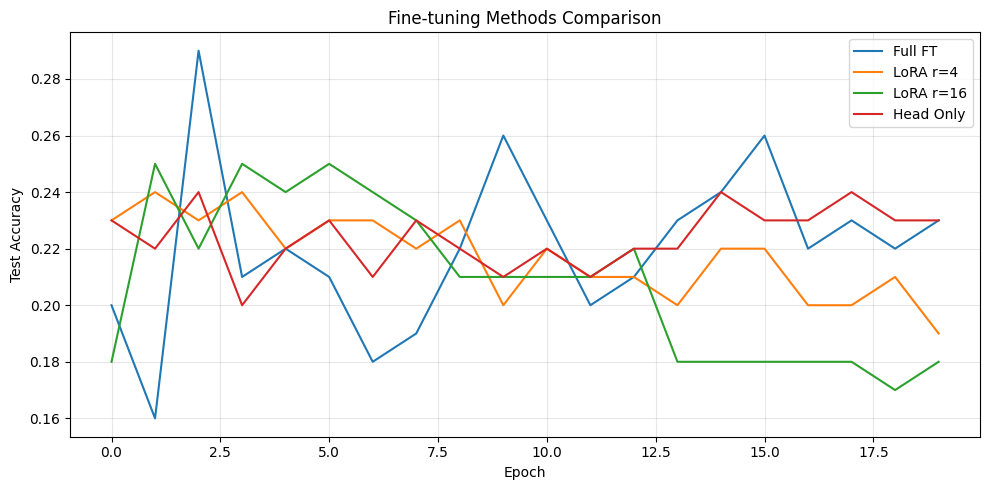


→ 圖表儲存至 llm/plots/03_lora_comparison.png


In [5]:
print("\n" + "=" * 60)
print("4. LoRA 微調實驗")
print("=" * 60)

from sklearn.datasets import fetch_20newsgroups
from torch.utils.data import DataLoader, TensorDataset

# 建立簡單的文字分類資料
np.random.seed(42)
vocab_size = 200
num_classes = 5
num_samples = 500
seq_len = 20

X = torch.randint(0, vocab_size, (num_samples, seq_len))
y = torch.randint(0, num_classes, (num_samples,))

X_tr, X_te = X[:400], X[400:]
y_tr, y_te = y[:400], y[400:]
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_and_eval(model, name, epochs=20):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            loss = criterion(model(bx), by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_te.to(device)).argmax(1)
            acc = (preds == y_te.to(device)).float().mean().item()
            history.append(acc)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  {name:20s}: Acc={acc:.2%}, Trainable={trainable:,}/{total:,} "
          f"({trainable/total:.1%})")
    return history


print(f"{'Method':>20s}: {'Acc':>8s}, {'Trainable Params'}")
print("-" * 60)

histories = {}

# Full fine-tuning
torch.manual_seed(42)
model_full = SimpleTransformer(vocab_size, d_model=64, num_layers=2, num_classes=num_classes)
histories['Full FT'] = train_and_eval(model_full, 'Full Fine-tuning')

# LoRA r=4
torch.manual_seed(42)
model_lora4 = SimpleTransformer(vocab_size, d_model=64, num_layers=2, num_classes=num_classes)
for p in model_lora4.parameters():
    p.requires_grad = False
apply_lora(model_lora4, rank=4)
for p in model_lora4.head.parameters():
    p.requires_grad = True
histories['LoRA r=4'] = train_and_eval(model_lora4, 'LoRA (r=4)')

# LoRA r=16
torch.manual_seed(42)
model_lora16 = SimpleTransformer(vocab_size, d_model=64, num_layers=2, num_classes=num_classes)
for p in model_lora16.parameters():
    p.requires_grad = False
apply_lora(model_lora16, rank=16)
for p in model_lora16.head.parameters():
    p.requires_grad = True
histories['LoRA r=16'] = train_and_eval(model_lora16, 'LoRA (r=16)')

# Head only
torch.manual_seed(42)
model_head = SimpleTransformer(vocab_size, d_model=64, num_layers=2, num_classes=num_classes)
for p in model_head.parameters():
    p.requires_grad = False
for p in model_head.head.parameters():
    p.requires_grad = True
histories['Head Only'] = train_and_eval(model_head, 'Head Only')

# 畫圖
fig, ax = plt.subplots(figsize=(10, 5))
for name, hist in histories.items():
    ax.plot(hist, label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Fine-tuning Methods Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-5-modern/llm/plots/03_lora_comparison.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 llm/plots/03_lora_comparison.png")

## 5. QLoRA 和量化

In [6]:
print("\n" + "=" * 60)
print("5. QLoRA — 量化 + LoRA")
print("=" * 60)

print("""
QLoRA (Quantized LoRA):
  在量化的模型上做 LoRA → 更省記憶體

  量化：
    FP32 (4 bytes) → FP16 (2 bytes) → INT8 (1 byte) → INT4 (0.5 bytes)

  LLaMA-7B 的記憶體需求：
    FP32: 28 GB
    FP16: 14 GB
    INT8:  7 GB
    INT4:  3.5 GB ← QLoRA 用這個！加上 LoRA 的小參數

  QLoRA 的三個關鍵：
    1. 4-bit NormalFloat (NF4): 比 INT4 更適合正態分佈的權重
    2. Double Quantization: 連量化的常數也量化
    3. Paged Optimizers: 優化器狀態放到 CPU 記憶體

  效果：
    一張 24GB 的 GPU (RTX 4090) 就能微調 65B 的模型！
""")

# 簡單展示量化的概念
print("--- 量化示範 ---")
weight = torch.randn(4, 4)
print(f"原始權重 (FP32):\n{weight}")

# 模擬 INT8 量化
scale = weight.abs().max() / 127
quantized = torch.round(weight / scale).clamp(-128, 127).to(torch.int8)
dequantized = quantized.float() * scale

print(f"\nINT8 量化後:\n{quantized}")
print(f"\n還原:\n{dequantized}")
print(f"\n量化誤差: {(weight - dequantized).abs().max():.6f}")


5. QLoRA — 量化 + LoRA

QLoRA (Quantized LoRA):
  在量化的模型上做 LoRA → 更省記憶體

  量化：
    FP32 (4 bytes) → FP16 (2 bytes) → INT8 (1 byte) → INT4 (0.5 bytes)

  LLaMA-7B 的記憶體需求：
    FP32: 28 GB
    FP16: 14 GB
    INT8:  7 GB
    INT4:  3.5 GB ← QLoRA 用這個！加上 LoRA 的小參數

  QLoRA 的三個關鍵：
    1. 4-bit NormalFloat (NF4): 比 INT4 更適合正態分佈的權重
    2. Double Quantization: 連量化的常數也量化
    3. Paged Optimizers: 優化器狀態放到 CPU 記憶體

  效果：
    一張 24GB 的 GPU (RTX 4090) 就能微調 65B 的模型！

--- 量化示範 ---
原始權重 (FP32):
tensor([[-0.2541,  0.5580,  0.0278, -0.8917],
        [ 0.5744,  0.8974, -0.2599, -0.2256],
        [-0.5616, -2.5959, -1.1221,  0.0931],
        [ 1.4511, -1.3391, -1.0330,  0.2935]])

INT8 量化後:
tensor([[ -12,   27,    1,  -44],
        [  28,   44,  -13,  -11],
        [ -27, -127,  -55,    5],
        [  71,  -66,  -51,   14]], dtype=torch.int8)

還原:
tensor([[-0.2453,  0.5519,  0.0204, -0.8994],
        [ 0.5723,  0.8994, -0.2657, -0.2248],
        [-0.5519, -2.5959, -1.1242,  0.1022],
        [ 1.4513, -1.349

## 6. 實務指南

In [7]:
print("\n" + "=" * 60)
print("6. PEFT 實務指南")
print("=" * 60)

print("""
使用 Hugging Face PEFT 庫的標準流程：

  from peft import LoraConfig, get_peft_model, TaskType

  # 1. 載入模型
  model = AutoModelForCausalLM.from_pretrained(
      "meta-llama/Llama-2-7b-hf",
      load_in_4bit=True,                    # QLoRA
      quantization_config=bnb_config,
  )

  # 2. 設定 LoRA
  lora_config = LoraConfig(
      r=16,                    # LoRA 秩
      lora_alpha=32,           # 縮放因子
      target_modules=[         # 要加 LoRA 的層
          "q_proj", "k_proj", "v_proj", "o_proj",
          "gate_proj", "up_proj", "down_proj",
      ],
      lora_dropout=0.05,
      bias="none",
      task_type=TaskType.CAUSAL_LM,
  )

  # 3. 應用 LoRA
  model = get_peft_model(model, lora_config)
  model.print_trainable_parameters()

  # 4. 訓練（用 transformers Trainer 或自己寫 loop）
  trainer = Trainer(model=model, ...)
  trainer.train()

  # 5. 存檔（只存 LoRA 的參數，通常只有幾 MB）
  model.save_pretrained("my-lora-adapter")

  # 6. 載入
  model = AutoModelForCausalLM.from_pretrained("base-model")
  model = PeftModel.from_pretrained(model, "my-lora-adapter")

  LoRA 超參數建議：
    r=8~32:    大部分情況 r=16 就夠了
    alpha=2r:  alpha = 2 × r 是常見的設定
    target:    至少加在 attention 的 Q, V 投影上
    dropout:   0.05~0.1
""")


6. PEFT 實務指南

使用 Hugging Face PEFT 庫的標準流程：

  from peft import LoraConfig, get_peft_model, TaskType

  # 1. 載入模型
  model = AutoModelForCausalLM.from_pretrained(
      "meta-llama/Llama-2-7b-hf",
      load_in_4bit=True,                    # QLoRA
      quantization_config=bnb_config,
  )

  # 2. 設定 LoRA
  lora_config = LoraConfig(
      r=16,                    # LoRA 秩
      lora_alpha=32,           # 縮放因子
      target_modules=[         # 要加 LoRA 的層
          "q_proj", "k_proj", "v_proj", "o_proj",
          "gate_proj", "up_proj", "down_proj",
      ],
      lora_dropout=0.05,
      bias="none",
      task_type=TaskType.CAUSAL_LM,
  )

  # 3. 應用 LoRA
  model = get_peft_model(model, lora_config)
  model.print_trainable_parameters()

  # 4. 訓練（用 transformers Trainer 或自己寫 loop）
  trainer = Trainer(model=model, ...)
  trainer.train()

  # 5. 存檔（只存 LoRA 的參數，通常只有幾 MB）
  model.save_pretrained("my-lora-adapter")

  # 6. 載入
  model = AutoModelForCausalLM.from_pretrained("base-model")
  model

## 小結

In [8]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
微調方法比較：

  方法             可訓練參數   GPU 記憶體   效果    難度
  ──────────────────────────────────────────────────
  Full FT         100%        極高       最好     高
  LoRA            ~1%         低         接近FT   低
  QLoRA           ~1%         很低       接近FT   低
  Head Only       <0.1%       很低       差       最低
  Adapter         ~2-3%       低         不錯     中
  Prefix Tuning   ~0.1%       低         不錯     中

  實務選擇：
    有多張 A100 → Full Fine-tuning
    有一張好 GPU → LoRA
    只有消費級 GPU → QLoRA
    GPU 很小 → 用 API (Claude/GPT) + Prompting

  LoRA 的核心公式：
    W' = W + BA    (W 凍結, 只訓練 B 和 A)
    B: (d, r), A: (r, d)    r << d

  工具推薦：
    - Hugging Face PEFT: LoRA, QLoRA, Adapter
    - Hugging Face TRL: RLHF, DPO 訓練
    - Axolotl: 一站式微調工具
    - LLaMA-Factory: 中文友好的微調框架

═══════════════════════════════════════════
  Phase 5 完成！
  你現在有了從基礎到前沿的完整 AI/ML 知識地圖。
═══════════════════════════════════════════
""")


小結

微調方法比較：

  方法             可訓練參數   GPU 記憶體   效果    難度
  ──────────────────────────────────────────────────
  Full FT         100%        極高       最好     高
  LoRA            ~1%         低         接近FT   低
  QLoRA           ~1%         很低       接近FT   低
  Head Only       <0.1%       很低       差       最低
  Adapter         ~2-3%       低         不錯     中
  Prefix Tuning   ~0.1%       低         不錯     中

  實務選擇：
    有多張 A100 → Full Fine-tuning
    有一張好 GPU → LoRA
    只有消費級 GPU → QLoRA
    GPU 很小 → 用 API (Claude/GPT) + Prompting

  LoRA 的核心公式：
    W' = W + BA    (W 凍結, 只訓練 B 和 A)
    B: (d, r), A: (r, d)    r << d

  工具推薦：
    - Hugging Face PEFT: LoRA, QLoRA, Adapter
    - Hugging Face TRL: RLHF, DPO 訓練
    - Axolotl: 一站式微調工具
    - LLaMA-Factory: 中文友好的微調框架

═══════════════════════════════════════════
  Phase 5 完成！
  你現在有了從基礎到前沿的完整 AI/ML 知識地圖。
═══════════════════════════════════════════

